In [ ]:
%load_ext autoreload
%autoreload 2
%env CUDA_VISIBLE_DEVICES=1

import numpy as np
import sys
import os
import matplotlib.pyplot as plt
import vis_utils

from utils.utils import get_path
from utils.io_utils import load_multiple_res
from utils.toydata_utils import get_toy_data
from utils.fig_utils import dataset_to_print, plot_dgm_loops, dist_to_print
from utils.pd_utils import sort_cycle

from vis_utils.loaders import load_dataset
from vis_utils.plot import plot_scatter
from vis_utils.utils import load_dict, save_dict
from vis_utils.tsne_wrapper import TSNEwrapper
from openTSNE.affinity import Affinities

import umap
from ripser import Rips
from ripser.ripser import get_greedy_perm

from mpl_toolkits.axes_grid1 import make_axes_locatable

from matplotlib import collections  as mc
from matplotlib.colors import Normalize
import matplotlib.cm

from openTSNE.nearest_neighbors import PrecomputedNeighbors
from openTSNE.affinity import PerplexityBasedNN

from vis_utils.utils import kNN_graph, kNN_dists
from scipy.spatial.distance import pdist, squareform
import glasbey
import scipy.sparse
import networkx as nx

from sklearn.decomposition import PCA

from persim import plot_diagrams
from utils.pd_utils import get_life_times
import pandas as pd

from vis_utils.rnaseqTools import geneSelection, sparseload
import pickle
import torch
import urllib.request
import requests
 
from scipy.linalg import orthogonal_procrustes
from scipy.spatial import procrustes

# conclusion and decision.....?
i personally find mask_56IT the best. mask_56IT2 miss the island right below the olive island, and could be interesting to explore the island on the bottom, which is missing in mask_56ITCTX

In [771]:
root_path = get_path("data")
seeds = [0]
seed = 0
k = 15
n_epochs = 500
n_early_epochs = 250
perplexity = None    
rescale_tsne = True
file_name = os.path.join(root_path,
                         "yao_10x_male",
                         f"tsne_bin_k_{k}_n_epochs_{n_epochs}_n_early_epochs_{n_early_epochs}_seed_{seed}_init_pca_rescale_{rescale_tsne}.pkl")
tsne_data = load_dict(file_name)
embd = tsne_data["embds"][-1]

In [772]:
_, _, _, _, full_d = load_dataset(root_path, "yao_10x_male", k=k)

In [773]:
cluster_56IT = [cluster for i, cluster in enumerate(full_d["clusterNames"]) 
              if "L6 IT" in cluster or "L5 IT" in cluster or "L5/6 IT" in cluster]
idx_56IT = [i for i, cluster in enumerate(full_d["clusterNames"]) 
              if "L6 IT" in cluster or "L5 IT" in cluster or "L5/6 IT" in cluster]
mask_56IT = [idx in idx_56IT for idx in full_d['clusters']]

In [434]:
full_d['clusterColors'][full_d['clusters'][mask_56IT]]

array(['#4EAC9C', '#89A25B', '#4A9E9E', ..., '#4E9E9E', '#A7A322',
       '#0BBEBE'], dtype='<U7')

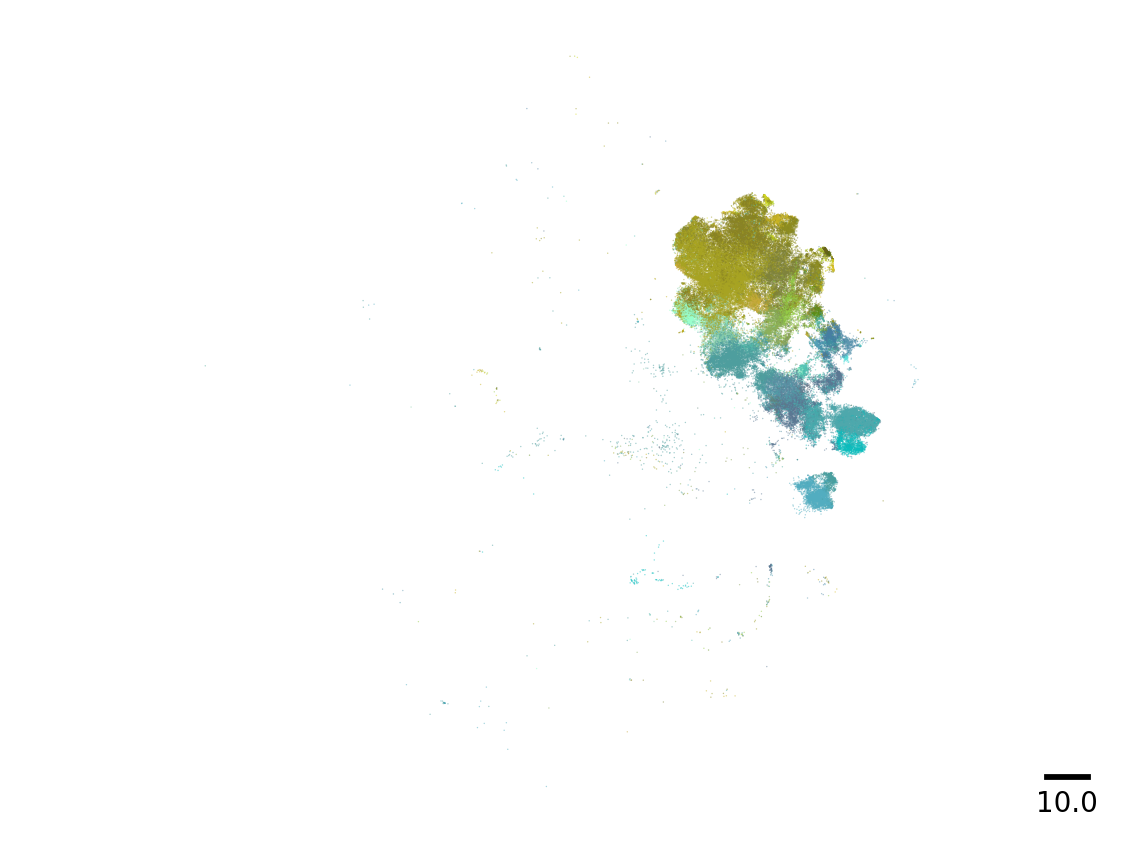

In [435]:
fig, ax = plt.subplots()
plot_scatter(ax, embd[mask_56IT], y=full_d['clusterColors'][full_d['clusters'][mask_56IT]])

In [774]:
cluster_56ITCTX = [cluster for i, cluster in enumerate(full_d["clusterNames"]) 
              if "L6 IT CTX" in cluster or "L5 IT CTX" in cluster or "L5/6 IT CTX" in cluster]
idx_56ITCTX = [i for i, cluster in enumerate(full_d["clusterNames"]) 
              if "L6 IT CTX" in cluster or "L5 IT CTX" in cluster or "L5/6 IT CTX" in cluster]
mask_56ITCTX = [idx in idx_56ITCTX for idx in full_d['clusters']]

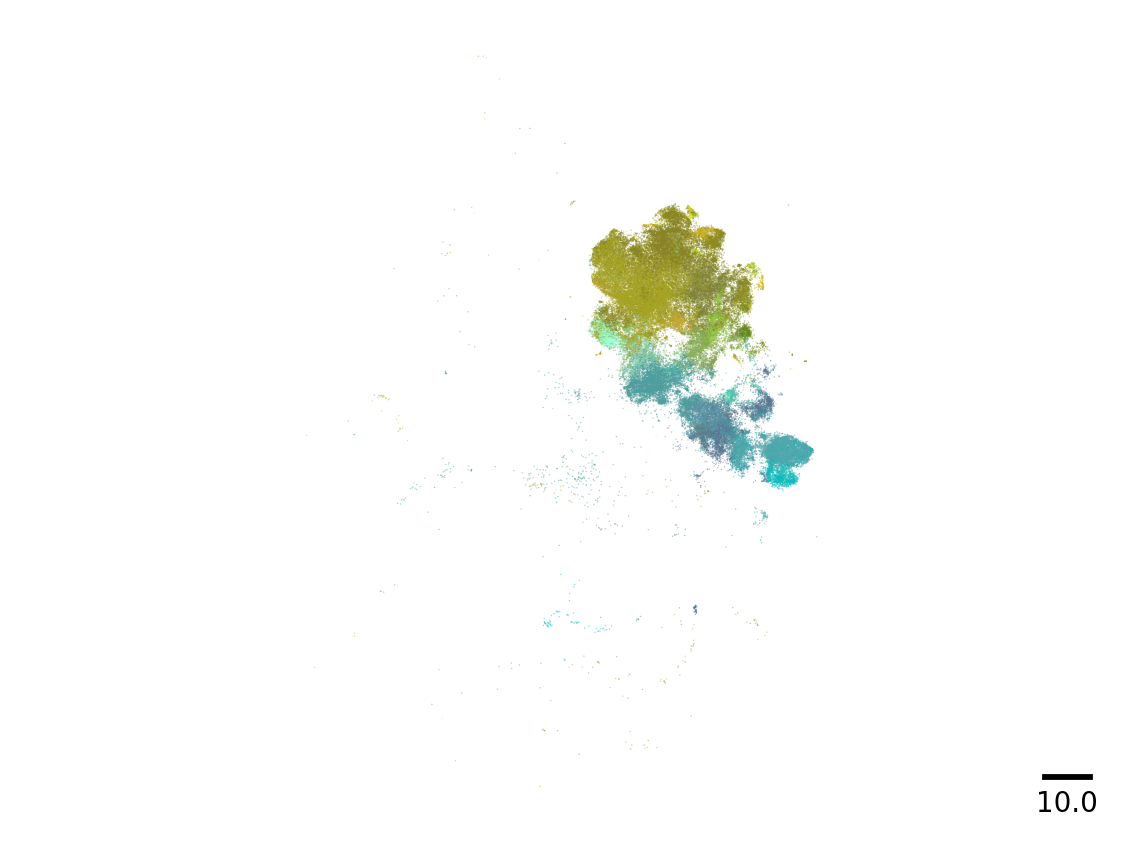

In [775]:
fig, ax = plt.subplots()
plot_scatter(ax, embd[mask_56ITCTX], y=full_d['clusterColors'][full_d['clusters'][mask_56ITCTX]])

In [776]:
cluster_56IT2 = [cluster for i, cluster in enumerate(full_d["clusterNames"]) 
              if "L6 IT" in cluster or "L5 IT" in cluster]
idx_56IT2 = [i for i, cluster in enumerate(full_d["clusterNames"]) 
              if "L6 IT" in cluster or "L5 IT" in cluster]
mask_56IT2 = [idx in idx_56IT2 for idx in full_d['clusters']]

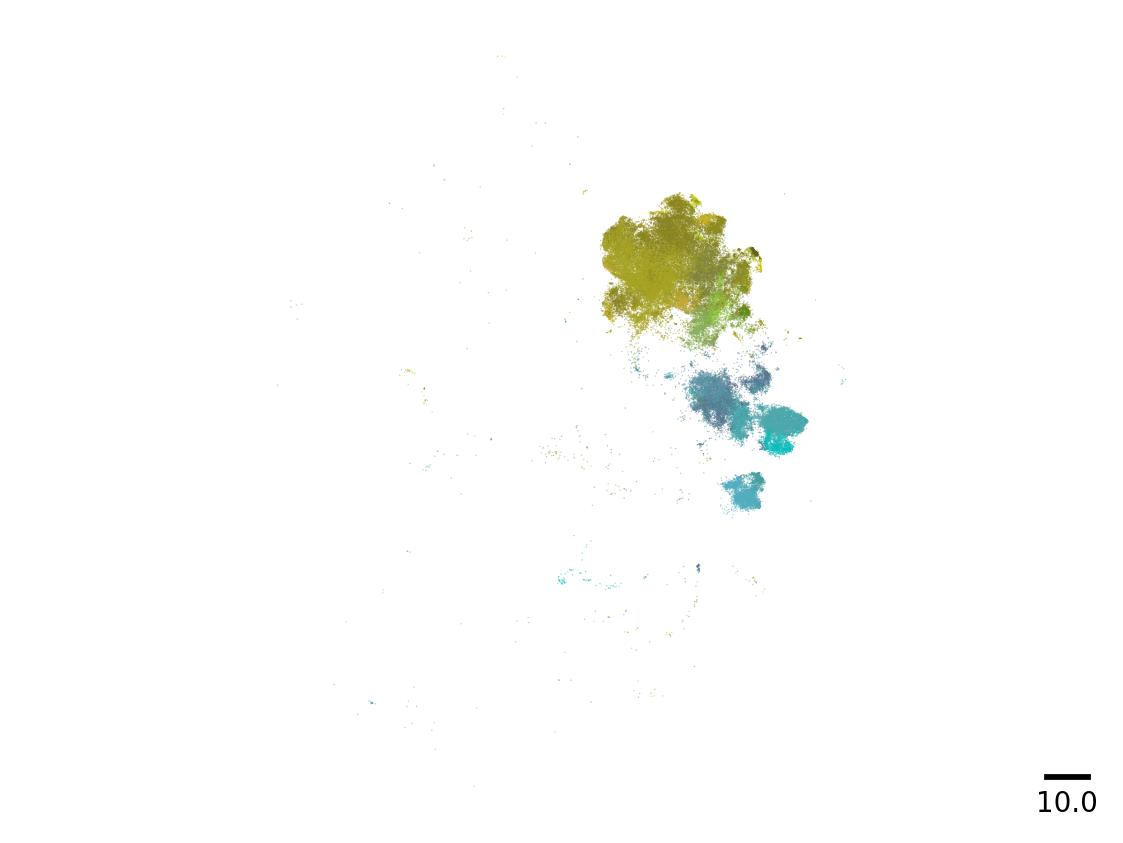

In [451]:
fig, ax = plt.subplots()
plot_scatter(ax, embd[mask_56IT2], y=full_d['clusterColors'][full_d['clusters'][mask_56IT2]])

# check loops in different condition... the 7*7 thingy...

In [767]:
distances = {
    "euclidean": [{}],
        "diffusion": [
        {"k": 15, "t": 8, "kernel": "sknn", "include_self": False},
        {"k": 100, "t": 8, "kernel": "sknn", "include_self": False},
        {"k": 15, "t": 64, "kernel": "sknn", "include_self": False},
        {"k": 100, "t": 64, "kernel": "sknn", "include_self": False},
    ],
    "eff_res": [
        {"corrected": True, "weighted": False, "k": 15, "disconnect": True},
        {"corrected": True, "weighted": False, "k": 100, "disconnect": True},
    ],
}

In [440]:
all_res = load_multiple_res(datasets="yao_10x_male_green_56IT_0_10k", n=None, embd_dims=None, sigmas=None, distances=distances, seeds=seeds, root_path=root_path, n_threads=1)

Done with yao_10x_male_green_0_10k None euclidean n_outliers=0, perturbation=None
Done with yao_10x_male_green_0_10k None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_green_0_10k None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_green_0_10k None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_green_0_10k None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_green_0_10k None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with yao_10x_male_green_0_10k None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None


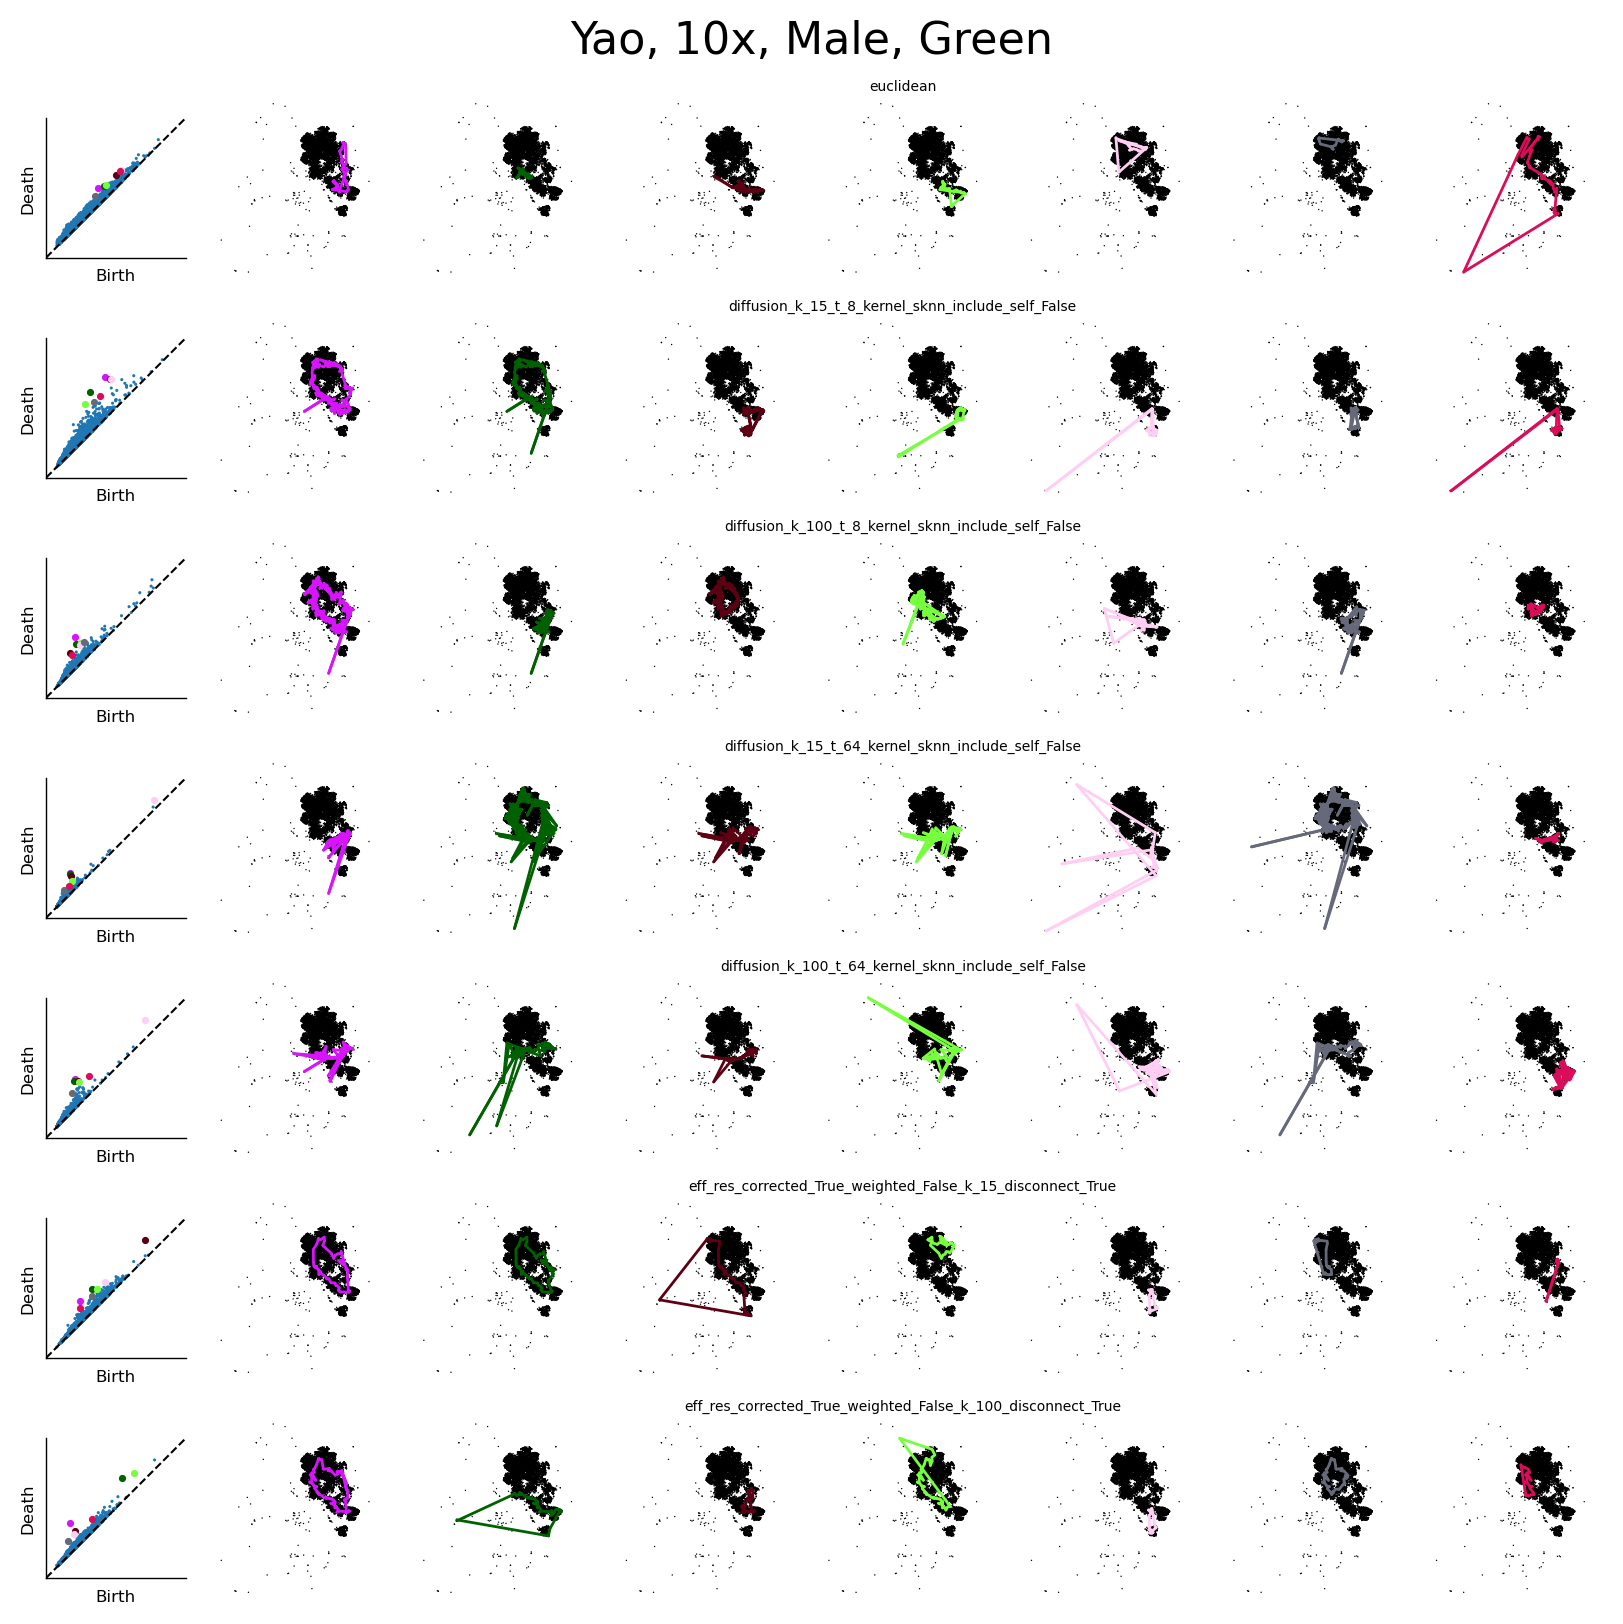

In [446]:

n_exp = sum([len(all_res[distance]) for distance in distances.keys()])
n_cols = 8
mid_col = np.floor(n_cols/2)
plot_loops = True

width_ratios = [0.75] + [1] * (n_cols-1)

fig, ax = plt.subplots(nrows=n_exp, ncols=n_cols, figsize=(8, 8), constrained_layout=True, width_ratios=width_ratios)
seed = 0
row = 0
for i, distance in enumerate(distances.keys()):
    for j, full_dist in enumerate(all_res[distance]):
        # if distance == "eff_res" and "k_15" not in full_dist: continue
        res = all_res[distance][full_dist]      
        
        if len(res["dgms"][1]) != 0:
            ax[row][int(mid_col)].set_title(full_dist, fontsize=5)
            np.random.seed(0)
            mm_g = np.random.choice(sum(mask_56IT), 10000, replace=False)            
            plot_dgm_loops(res, embd[mask_56IT][mm_g], y="k", n_loops=0, ax=ax[row], plot_only=[1], style=style_file, linewidth=1, plot_loops=plot_loops)

        else:
            ax[row][int(mid_col)].set_title(full_dist, fontsize=5)
            revised = res["dgms"]
            # revised[1] = np.array([[0,0],[1,1]])
            revised[1] = np.zeros((1,2))
            ax0 = ax[row][0]
            ax0.legend().set_visible(False)
            ax0.set_xticks([])
            ax0.set_yticks([])
            ax0.set_ylabel("Death")
            ax0.set_xlabel("Birth")
            plot_diagrams(revised, show=False, ax=ax0, size=0, plot_only=[1])
            # ax0.plot([-1, 1], [-1, 1], "--", c = 'k', markersize=0.1)
            for i in range(n_cols-1):
                plot_scatter(ax[row][i+1], embd, y="k", s=0.2, alpha=1, cmap="tab20", scalebar=False)
        # for s in range(n_cols-1):
            # ax[row][s+1].set_ylim(10, 80)
        
        ax[row][0].legend().set_visible(False)
        ax[row][0].set_xticks([])
        ax[row][0].set_yticks([])
        ax[row][0].set_ylabel("Death")
        # ax[row][int(mid_col)].set_title(full_dist)
        row+=1
fig.suptitle("Yao, 10x, Male, Green", fontsize = 16)       
plt.show()
# fig.savefig(os.path.join(get_path("figures"), f"tasic_purple_lamp5_77_woLhx6.png"), dpi=300)
# lhx6 should be a little island at upper right corner... if you compare wit htasic_purple_lamp5_77.png, that one includes Lhx6

In [777]:
all_res = load_multiple_res(datasets="yao_10x_male_green_56ITCTX_0_10k", n=None, embd_dims=None, sigmas=None, distances=distances, seeds=seeds, root_path=root_path, n_threads=1)

Done with yao_10x_male_green_56ITCTX_0_10k None euclidean n_outliers=0, perturbation=None
Done with yao_10x_male_green_56ITCTX_0_10k None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_green_56ITCTX_0_10k None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_green_56ITCTX_0_10k None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_green_56ITCTX_0_10k None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_green_56ITCTX_0_10k None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with yao_10x_male_green_56ITCTX_0_10k None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None


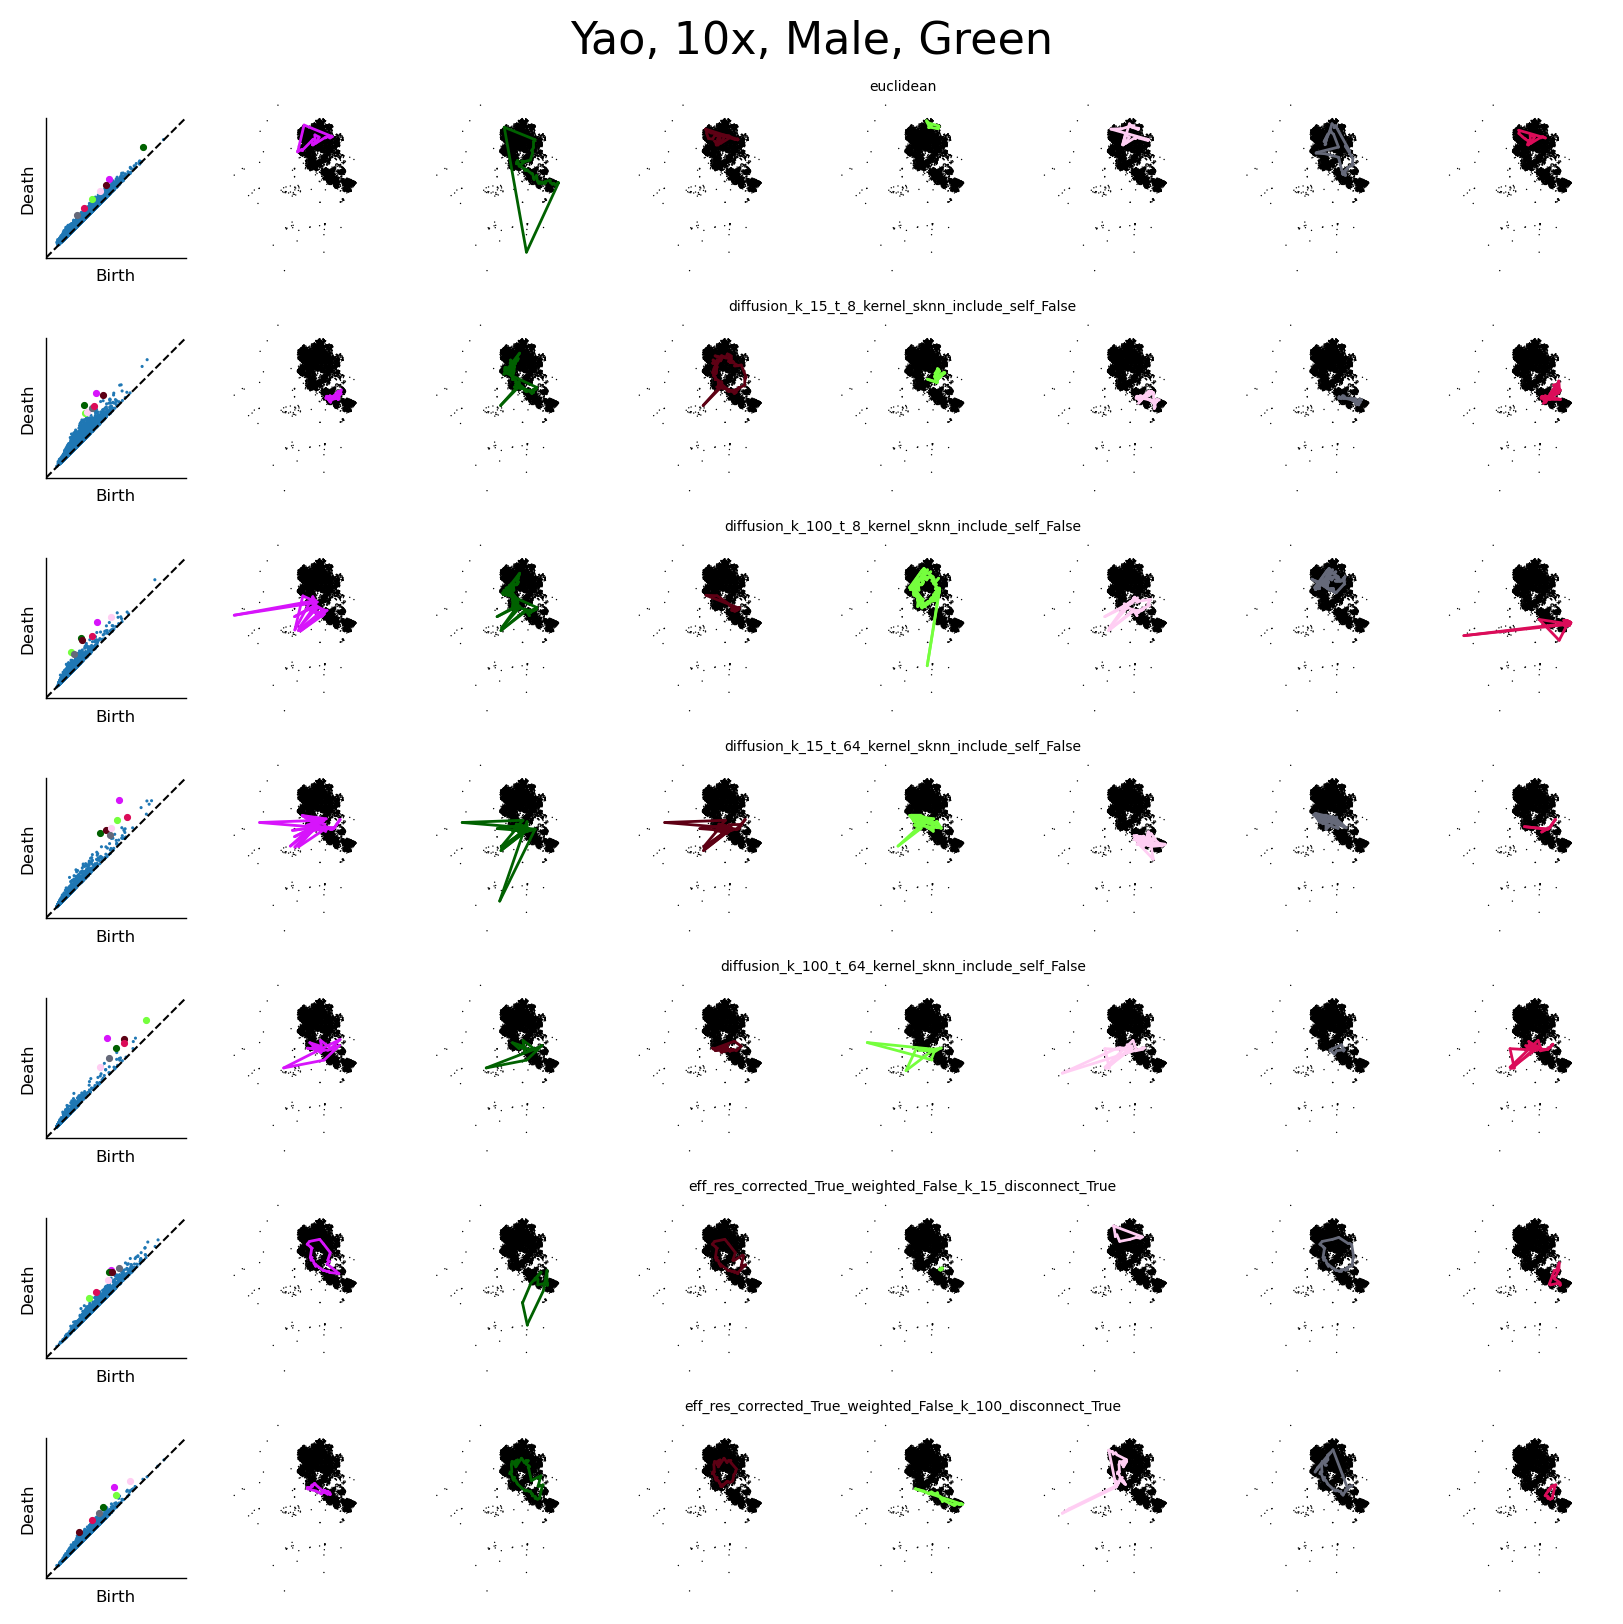

In [778]:

n_exp = sum([len(all_res[distance]) for distance in distances.keys()])
n_cols = 8
mid_col = np.floor(n_cols/2)
plot_loops = True

width_ratios = [0.75] + [1] * (n_cols-1)

fig, ax = plt.subplots(nrows=n_exp, ncols=n_cols, figsize=(8, 8), constrained_layout=True, width_ratios=width_ratios)
seed = 0
row = 0
for i, distance in enumerate(distances.keys()):
    for j, full_dist in enumerate(all_res[distance]):
        # if distance == "eff_res" and "k_15" not in full_dist: continue
        res = all_res[distance][full_dist]      
        
        if len(res["dgms"][1]) != 0:
            ax[row][int(mid_col)].set_title(full_dist, fontsize=5)
            np.random.seed(0)
            mm_g = np.random.choice(sum(mask_56ITCTX), 10000, replace=False)            
            plot_dgm_loops(res, embd[mask_56ITCTX][mm_g], y="k", n_loops=0, ax=ax[row], plot_only=[1], style=style_file, linewidth=1, plot_loops=plot_loops)

        else:
            ax[row][int(mid_col)].set_title(full_dist, fontsize=5)
            revised = res["dgms"]
            # revised[1] = np.array([[0,0],[1,1]])
            revised[1] = np.zeros((1,2))
            ax0 = ax[row][0]
            ax0.legend().set_visible(False)
            ax0.set_xticks([])
            ax0.set_yticks([])
            ax0.set_ylabel("Death")
            ax0.set_xlabel("Birth")
            plot_diagrams(revised, show=False, ax=ax0, size=0, plot_only=[1])
            # ax0.plot([-1, 1], [-1, 1], "--", c = 'k', markersize=0.1)
            for i in range(n_cols-1):
                plot_scatter(ax[row][i+1], embd, y="k", s=0.2, alpha=1, cmap="tab20", scalebar=False)
        # for s in range(n_cols-1):
            # ax[row][s+1].set_ylim(10, 80)
        
        ax[row][0].legend().set_visible(False)
        ax[row][0].set_xticks([])
        ax[row][0].set_yticks([])
        ax[row][0].set_ylabel("Death")
        # ax[row][int(mid_col)].set_title(full_dist)
        row+=1
fig.suptitle("Yao, 10x, Male, Green", fontsize = 16)       
plt.show()
# fig.savefig(os.path.join(get_path("figures"), f"tasic_purple_lamp5_77_woLhx6.png"), dpi=300)
# lhx6 should be a little island at upper right corner... if you compare wit htasic_purple_lamp5_77.png, that one includes Lhx6

Done with yao_10x_male_green_56IT2_0_10k None euclidean n_outliers=0, perturbation=None
Done with yao_10x_male_green_56IT2_0_10k None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_green_56IT2_0_10k None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_green_56IT2_0_10k None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_green_56IT2_0_10k None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_green_56IT2_0_10k None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with yao_10x_male_green_56IT2_0_10k None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None


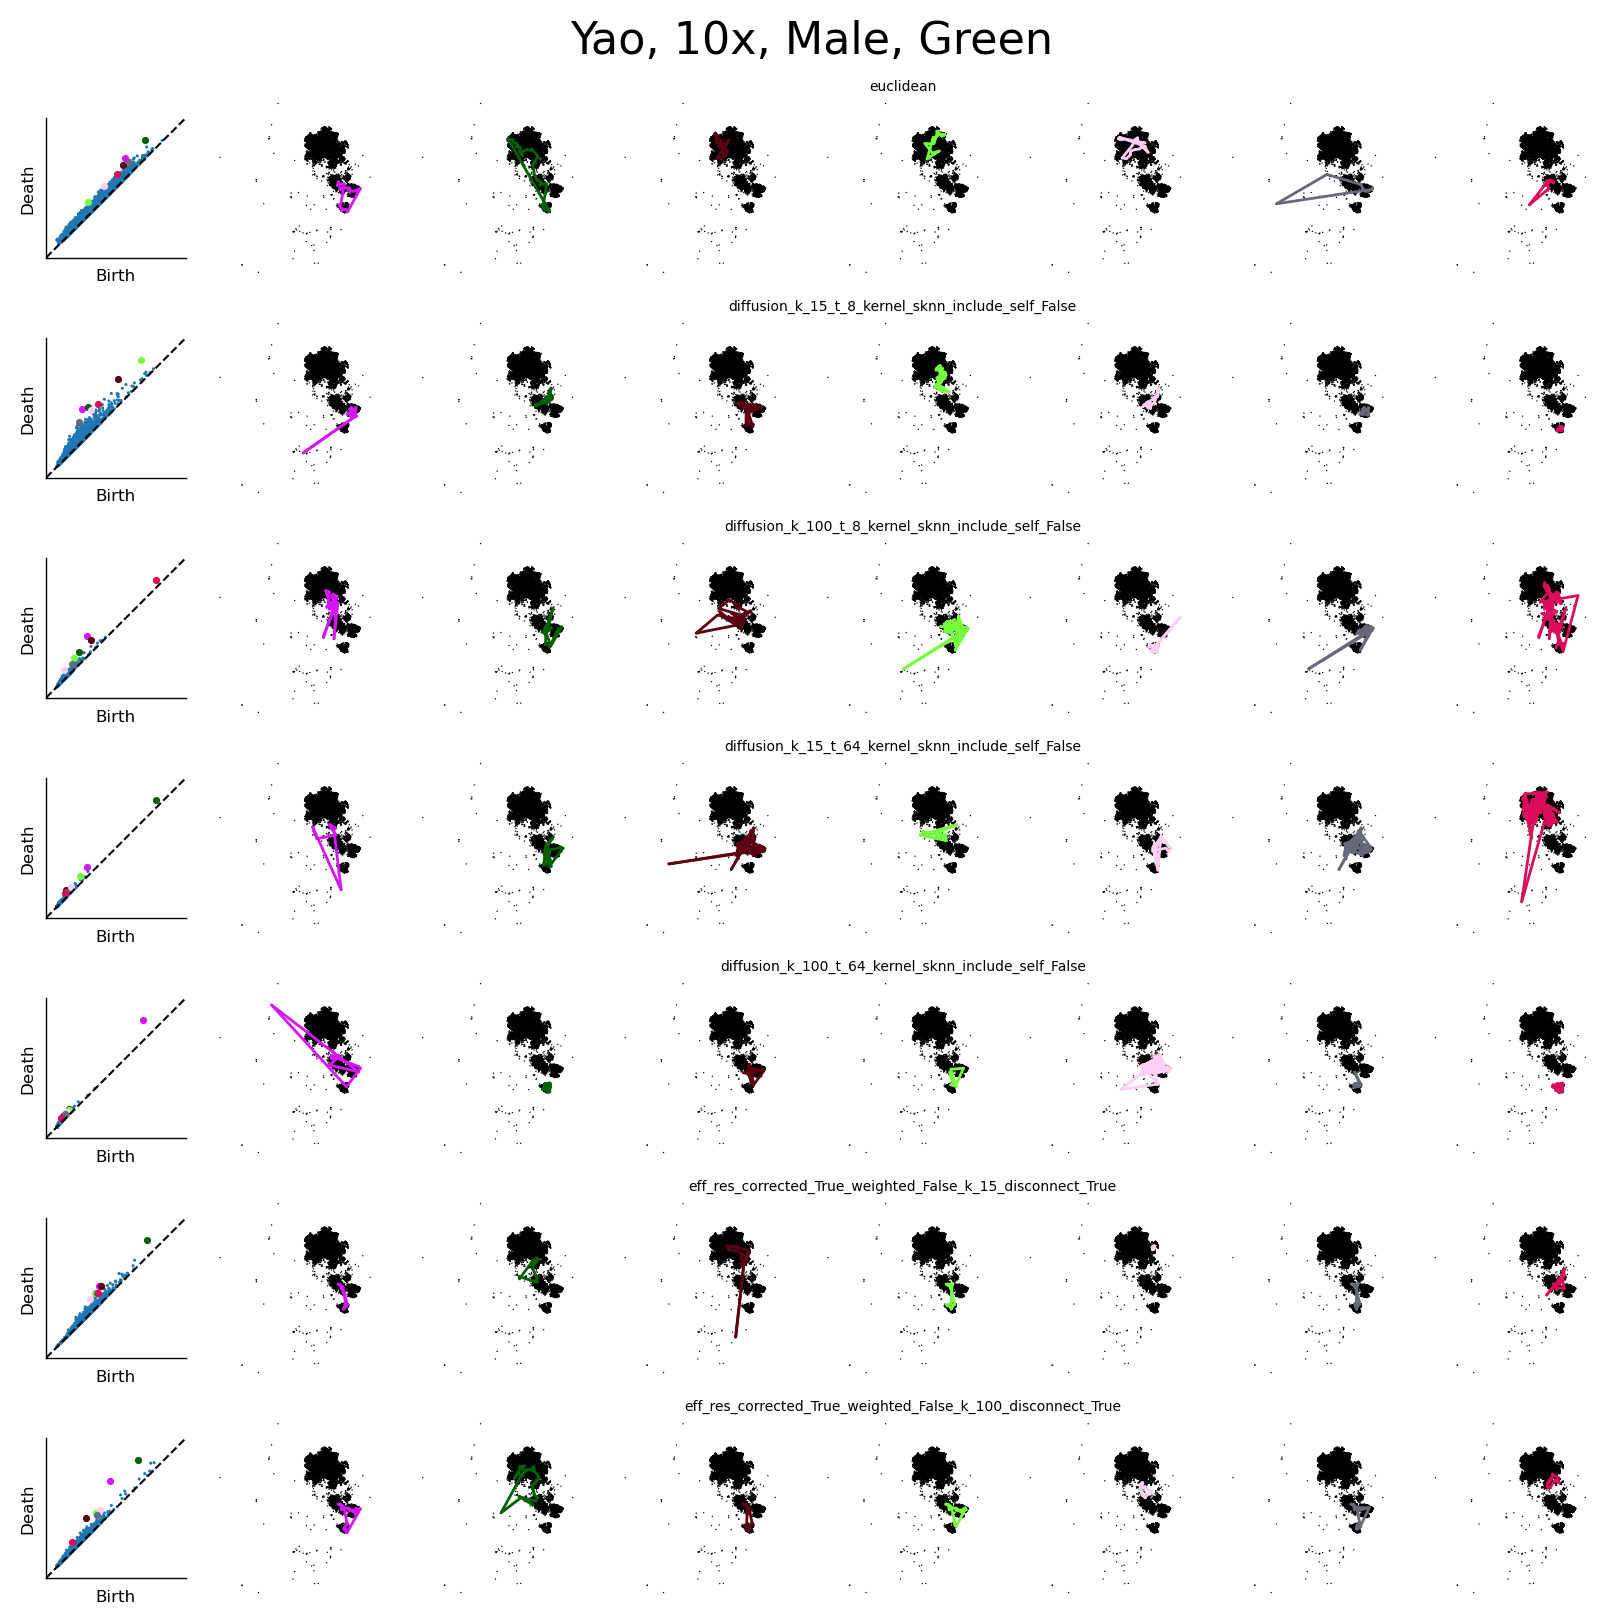

In [779]:
all_res = load_multiple_res(datasets="yao_10x_male_green_56IT2_0_10k", n=None, embd_dims=None, sigmas=None, distances=distances, seeds=seeds, root_path=root_path, n_threads=1)

n_exp = sum([len(all_res[distance]) for distance in distances.keys()])
n_cols = 8
mid_col = np.floor(n_cols/2)
plot_loops = True

width_ratios = [0.75] + [1] * (n_cols-1)

fig, ax = plt.subplots(nrows=n_exp, ncols=n_cols, figsize=(8, 8), constrained_layout=True, width_ratios=width_ratios)
seed = 0
row = 0
for i, distance in enumerate(distances.keys()):
    for j, full_dist in enumerate(all_res[distance]):
        # if distance == "eff_res" and "k_15" not in full_dist: continue
        res = all_res[distance][full_dist]      
        
        if len(res["dgms"][1]) != 0:
            ax[row][int(mid_col)].set_title(full_dist, fontsize=5)
            np.random.seed(0)
            mm_g = np.random.choice(sum(mask_56IT2), 10000, replace=False)            
            plot_dgm_loops(res, embd[mask_56IT2][mm_g], y="k", n_loops=0, ax=ax[row], plot_only=[1], style=style_file, linewidth=1, plot_loops=plot_loops)

        else:
            ax[row][int(mid_col)].set_title(full_dist, fontsize=5)
            revised = res["dgms"]
            # revised[1] = np.array([[0,0],[1,1]])
            revised[1] = np.zeros((1,2))
            ax0 = ax[row][0]
            ax0.legend().set_visible(False)
            ax0.set_xticks([])
            ax0.set_yticks([])
            ax0.set_ylabel("Death")
            ax0.set_xlabel("Birth")
            plot_diagrams(revised, show=False, ax=ax0, size=0, plot_only=[1])
            # ax0.plot([-1, 1], [-1, 1], "--", c = 'k', markersize=0.1)
            for i in range(n_cols-1):
                plot_scatter(ax[row][i+1], embd, y="k", s=0.2, alpha=1, cmap="tab20", scalebar=False)
        # for s in range(n_cols-1):
            # ax[row][s+1].set_ylim(10, 80)
        
        ax[row][0].legend().set_visible(False)
        ax[row][0].set_xticks([])
        ax[row][0].set_yticks([])
        ax[row][0].set_ylabel("Death")
        # ax[row][int(mid_col)].set_title(full_dist)
        row+=1
fig.suptitle("Yao, 10x, Male, Green", fontsize = 16)       
plt.show()
# fig.savefig(os.path.join(get_path("figures"), f"tasic_purple_lamp5_77_woLhx6.png"), dpi=300)
# lhx6 should be a little island at upper right corner... if you compare wit htasic_purple_lamp5_77.png, that one includes Lhx6